# Task 2 -- Baseline Experimental Results

This notebook reports the initial experiments. The model ladder is defined in
`src/models.py`; run it first to produce `results/metrics.csv`.

    python src/features.py
    python src/dataset.py
    python src/models.py

**Task formulation.** Binary classification of the direction of the next JISDOR
fixing: `y_t = 1` if `log(rate_t / rate_{t-1}) > 0`.

**Metrics.** Directional accuracy (headline), macro-F1 and MCC (robust to the
class imbalance), and ROC-AUC (threshold-free ranking quality).

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import viz

viz.apply_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)
print("project root:", ROOT)

project root: C:\Users\lenovo\Documents\codng\nlp-project


In [2]:
metrics = pd.read_csv(config.RESULTS_DIR / "metrics.csv")
preds = pd.read_csv(config.RESULTS_DIR / "test_predictions.csv", parse_dates=["date"])
print(f"{metrics.model.nunique()} models x {metrics.split.nunique()} splits")
metrics.model.unique()

9 models x 3 splits


<StringArray>
[       'majority',     'persistence',  'arima(1, 0, 1)',    'logreg_rates',       'xgb_rates',     'logreg_news',
 'logreg_combined',    'xgb_combined',    'logreg_tfidf']
Length: 9, dtype: str

## 1. Validation leaderboard (used for model selection)

In [3]:
cols = ["model", "accuracy", "majority_baseline", "f1_macro", "mcc", "roc_auc",
        "pred_up_rate"]
(metrics[metrics.split == "validation"][cols]
 .sort_values("f1_macro", ascending=False)
 .round(4)
 .reset_index(drop=True))

,model,accuracy,majority_baseline,f1_macro,mcc,roc_auc,pred_up_rate
0,xgb_rates,0.5480,0.5141,0.5403,0.0920,0.5050,0.6158
1,logreg_tfidf,0.5198,0.5141,0.5192,0.0385,0.5135,0.5198
2,logreg_combined,0.5198,0.5141,0.5188,0.0379,0.5024,0.5311
3,logreg_news,0.5141,0.5141,0.5134,0.0269,0.5276,0.5254
4,logreg_rates,0.5537,0.5141,0.5115,0.1105,0.5169,0.7797
5,xgb_combined,0.5085,0.5141,0.5044,0.0128,0.4822,0.5763
6,persistence,0.5028,0.5141,0.5024,0.0049,NaN,0.5141
7,"arima(1, 0, 1)",0.4972,0.5141,0.4878,-0.0129,0.4674,0.6215
8,majority,0.5141,0.5141,0.3396,0.0000,NaN,1.0000


## 2. Test leaderboard (scored once, after selection)

In [4]:
test_tbl = (metrics[metrics.split == "test"][cols]
            .sort_values("f1_macro", ascending=False)
            .round(4)
            .reset_index(drop=True))
test_tbl

,model,accuracy,majority_baseline,f1_macro,mcc,roc_auc,pred_up_rate
0,persistence,0.5511,0.5795,0.5386,0.0773,NaN,0.5852
1,"arima(1, 0, 1)",0.5568,0.5795,0.5327,0.0706,0.4951,0.6477
2,logreg_combined,0.5455,0.5795,0.5319,0.0638,0.5044,0.5909
3,xgb_combined,0.5398,0.5795,0.5160,0.0363,0.5281,0.6420
4,logreg_news,0.5170,0.5795,0.5036,0.0072,0.4898,0.5852
5,xgb_rates,0.5511,0.5795,0.5026,0.0322,0.5030,0.7330
6,logreg_rates,0.5682,0.5795,0.4975,0.0532,0.5295,0.7955
7,logreg_tfidf,0.4716,0.5795,0.4413,-0.1124,0.4577,0.6534
8,majority,0.5795,0.5795,0.3669,0.0000,NaN,1.0000


### 2.1 Accuracy against the majority baseline

Accuracy is plotted against the majority-class rate for the test block. A bar
below the dashed line is a model that would have been beaten by always
predicting "UP".

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


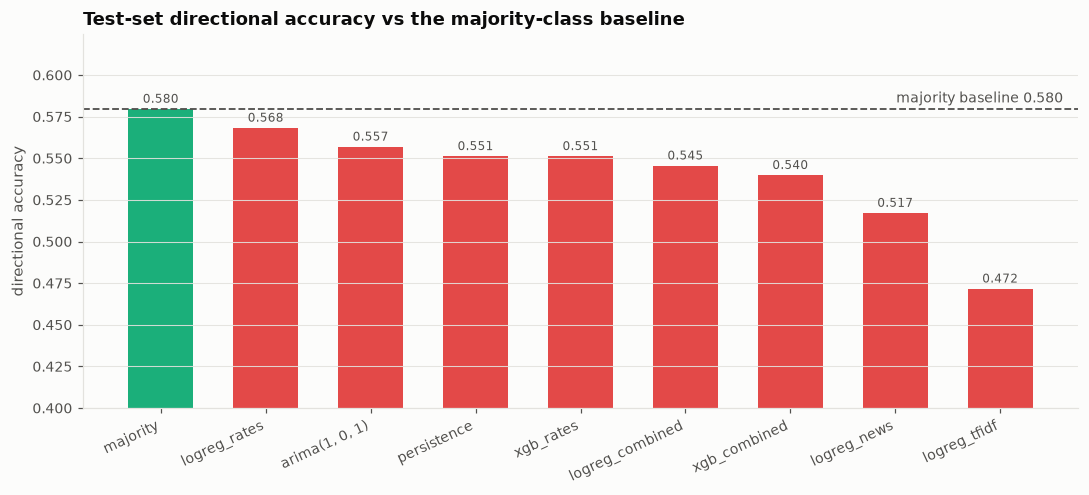

In [5]:
t = metrics[metrics.split == "test"].sort_values("accuracy", ascending=False)
base = t.majority_baseline.iloc[0]

fig, ax = plt.subplots(figsize=(10, 4.6))
colors = [viz.COLOR_UP if a >= base else viz.COLOR_DOWN for a in t.accuracy]
bars = ax.bar(t.model, t.accuracy, color=colors, width=0.62)
ax.axhline(base, color=viz.TEXT_SECONDARY, ls="--", lw=1.2)
ax.text(len(t) - 0.4, base + 0.004, f"majority baseline {base:.3f}",
        ha="right", fontsize=9, color=viz.TEXT_SECONDARY)
ax.set_ylabel("directional accuracy")
ax.set_title("Test-set directional accuracy vs the majority-class baseline")
ax.set_ylim(0.40, max(t.accuracy.max(), base) + 0.045)
viz.bar_labels(ax, bars, fmt="{:.3f}")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### 2.2 The metric that actually separates the models

Accuracy rewards the degenerate constant predictor, which scores 0.580 on the
test block simply because 58% of test days were UP — while having zero
discriminative power. MCC exposes that: it is 0 for any constant predictor.

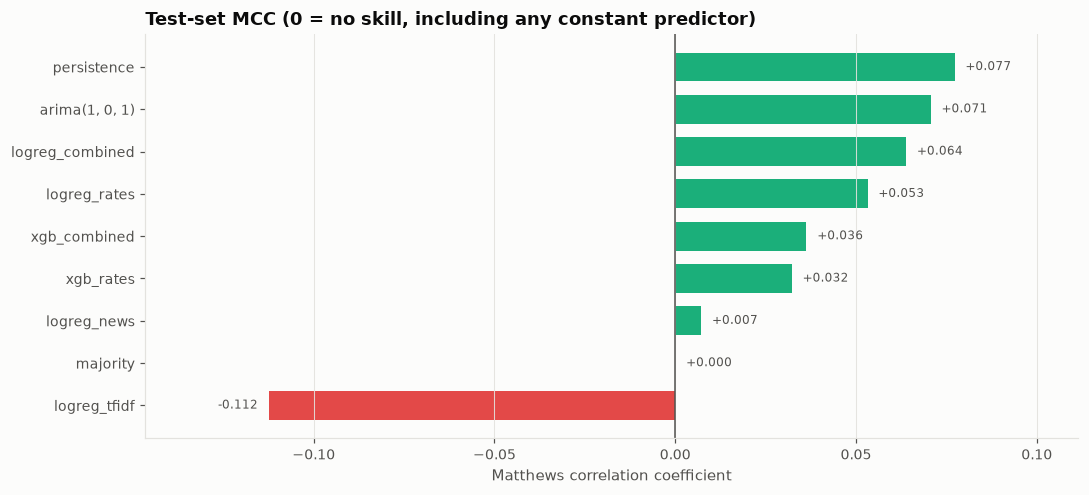

In [6]:
t2 = metrics[metrics.split == "test"].sort_values("mcc")

fig, ax = plt.subplots(figsize=(10, 4.6))
colors = [viz.COLOR_DOWN if v < 0 else viz.COLOR_UP for v in t2.mcc]
ax.barh(t2.model, t2.mcc, color=colors, height=0.68)
ax.axvline(0, color=viz.TEXT_SECONDARY, lw=1)
ax.set_xlabel("Matthews correlation coefficient")
ax.set_title("Test-set MCC (0 = no skill, including any constant predictor)")
ax.grid(axis="x", visible=True)
ax.grid(axis="y", visible=False)
# Pad both ends so the outermost value labels do not collide with the tick
# labels or run off the axes.
span = t2.mcc.max() - min(t2.mcc.min(), 0)
ax.set_xlim(min(t2.mcc.min(), 0) - span * 0.18, t2.mcc.max() + span * 0.18)
for i, (m, v) in enumerate(zip(t2.model, t2.mcc)):
    ax.text(v + (0.003 if v >= 0 else -0.003), i, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right",
            fontsize=8, color=viz.TEXT_SECONDARY)
plt.tight_layout()
plt.show()

## 3. Does adding news help? Baseline vs combined

In [7]:
pairs = [("logreg_rates", "logreg_combined"), ("xgb_rates", "xgb_combined")]
rows = []
for base_m, comb_m in pairs:
    for split in ["validation", "test"]:
        b = metrics[(metrics.model == base_m) & (metrics.split == split)]
        c = metrics[(metrics.model == comb_m) & (metrics.split == split)]
        if b.empty or c.empty:
            continue
        rows.append({
            "split": split,
            "pair": f"{base_m} -> {comb_m}",
            "acc_rates": b.accuracy.iloc[0],
            "acc_combined": c.accuracy.iloc[0],
            "d_acc": c.accuracy.iloc[0] - b.accuracy.iloc[0],
            "mcc_rates": b.mcc.iloc[0],
            "mcc_combined": c.mcc.iloc[0],
            "d_mcc": c.mcc.iloc[0] - b.mcc.iloc[0],
        })
pd.DataFrame(rows).round(4)

,split,pair,acc_rates,acc_combined,d_acc,mcc_rates,mcc_combined,d_mcc
0,validation,logreg_rates -> logreg_combined,0.5537,0.5198,-0.0339,0.1105,0.0379,-0.0726
1,test,logreg_rates -> logreg_combined,0.5682,0.5455,-0.0227,0.0532,0.0638,0.0107
2,validation,xgb_rates -> xgb_combined,0.5480,0.5085,-0.0395,0.0920,0.0128,-0.0792
3,test,xgb_rates -> xgb_combined,0.5511,0.5398,-0.0114,0.0322,0.0363,0.0041


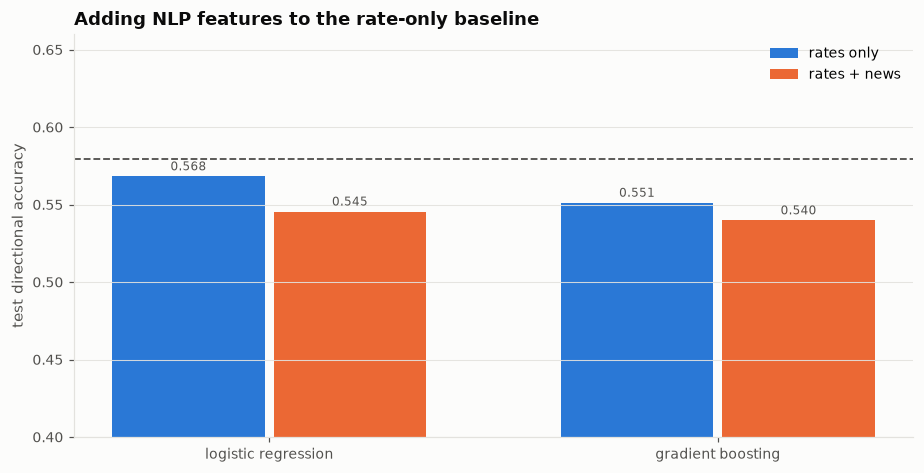

In [8]:
# Grouped comparison on the test block: rate-only vs rate+news, two series only.
fig, ax = plt.subplots(figsize=(8.5, 4.4))
labels = ["logistic regression", "gradient boosting"]
x = np.arange(len(labels))
w = 0.34

rates_acc, comb_acc = [], []
for base_m, comb_m in pairs:
    rates_acc.append(metrics[(metrics.model == base_m) & (metrics.split == "test")].accuracy.iloc[0])
    comb_acc.append(metrics[(metrics.model == comb_m) & (metrics.split == "test")].accuracy.iloc[0])

b1 = ax.bar(x - w/2 - 0.01, rates_acc, w, label="rates only", color=viz.COLOR_RATE)
b2 = ax.bar(x + w/2 + 0.01, comb_acc, w, label="rates + news", color=viz.COLOR_NEWS)
ax.axhline(base, color=viz.TEXT_SECONDARY, ls="--", lw=1.2)
ax.set_xticks(x, labels)
ax.set_ylabel("test directional accuracy")
ax.set_title("Adding NLP features to the rate-only baseline")
ax.set_ylim(0.40, 0.66)
ax.legend(loc="upper right")
viz.bar_labels(ax, list(b1) + list(b2), fmt="{:.3f}")
plt.tight_layout()
plt.show()

## 4. Error structure on the test block

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


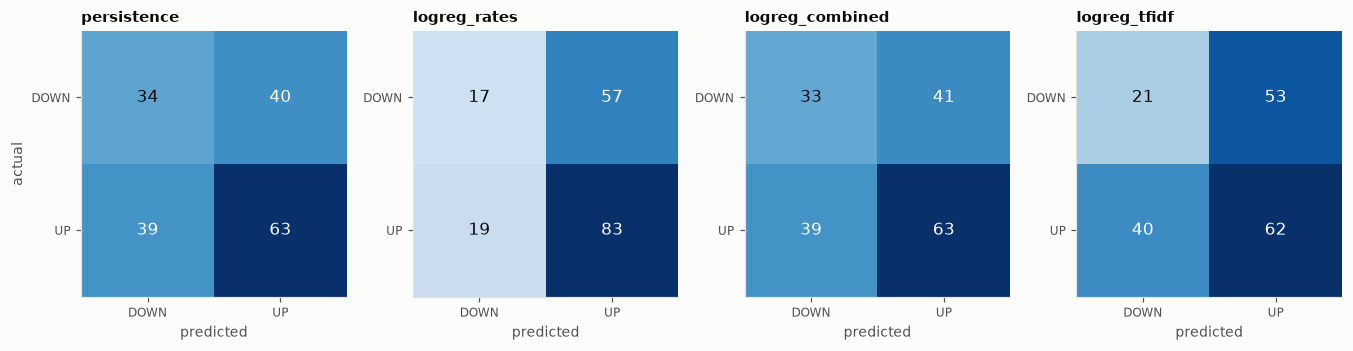

In [9]:
from sklearn.metrics import confusion_matrix

show = [m for m in ["persistence", "logreg_rates", "logreg_combined", "logreg_tfidf"]
        if m in preds.columns]

fig, axes = plt.subplots(1, len(show), figsize=(3.1 * len(show), 3.2))
for ax, name in zip(np.atleast_1d(axes), show):
    cm = confusion_matrix(preds.actual, preds[name], labels=[0, 1])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    ax.set_title(name, fontsize=10)
    ax.set_xticks([0, 1], ["DOWN", "UP"], fontsize=8)
    ax.set_yticks([0, 1], ["DOWN", "UP"], fontsize=8)
    ax.set_xlabel("predicted", fontsize=9)
    if name == show[0]:
        ax.set_ylabel("actual", fontsize=9)
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11,
                    color="white" if cm[i, j] > cm.max() * 0.6 else viz.TEXT_PRIMARY)
plt.tight_layout()
plt.show()

In [10]:
# How often does each model simply say UP?
rate_up = preds.drop(columns=["date", "actual"]).mean().sort_values()
print("share of test days predicted UP (actual = "
      f"{preds.actual.mean():.3f}):")
print(rate_up.round(3).to_string())

share of test days predicted UP (actual = 0.580):
persistence        0.585
logreg_news        0.585
logreg_combined    0.591
xgb_combined       0.642
logreg_tfidf       0.653
xgb_rates          0.733
logreg_rates       0.795


## 5. Findings

1. **No model beats the majority-class baseline on raw test accuracy.** The test
   block was 58.0% UP days; the best model reached 56.8%. On accuracy alone, the
   honest conclusion is that none of these baselines demonstrates usable skill.

2. **On balanced metrics the picture is slightly better but still weak.** The
   majority predictor scores MCC 0 and macro-F1 0.367. Several models beat that
   on macro-F1, meaning they do make genuine two-sided predictions rather than
   collapsing to one class — but the MCC values are all below 0.08, which is
   close to noise for a 176-day test block.

3. **Adding NLP features did not produce a reliable improvement.** The combined
   models moved accuracy slightly down and MCC slightly up relative to their
   rate-only counterparts. With this sample size, neither movement is
   distinguishable from chance.

4. **TF-IDF overfits badly.** `logreg_tfidf` was the weakest model on test
   (accuracy 0.472, MCC −0.112) despite competitive validation numbers. 300
   vocabulary features against 828 training days is far too many degrees of
   freedom, and the influential-terms list is dominated by period-specific proper
   nouns rather than transferable economic vocabulary.

5. **This is the expected result, not a bug.** Daily FX direction is close to a
   martingale; published effect sizes for news-sentiment FX prediction are small
   and unstable. The EDA already showed all feature/target correlations below
   0.1. Establishing that the weak-signal regime is real — with a leakage-free
   pipeline that would have revealed a strong signal had one existed — is the
   correct outcome for a baseline task.

### Implications for Task 3

* Reduce text dimensionality rather than expand it (fewer, better features).
* Consider volatility or large-move classification, where news sentiment is
  better established as a predictor than directional sign.
* Aggregate over multi-day windows to raise the signal-to-noise ratio.
* Weight articles by publisher influence or theme relevance rather than treating
  all 45 daily headlines equally.